In [2]:
import os
print(os.getcwd())

/content


In [3]:
from google.colab import files
uploaded = files.upload()

Saving GlobalTemperatures.csv to GlobalTemperatures.csv


In [5]:
import pandas as pd

df = pd.read_csv("GlobalTemperatures.csv")

df.head()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df = df[['dt','LandAverageTemperature','LandAverageTemperatureUncertainty']]

In [7]:
df['dt'] = pd.to_datetime(df['dt'])

In [8]:
df.dropna(inplace = True)

df.info

<bound method DataFrame.info of              dt  LandAverageTemperature  LandAverageTemperatureUncertainty
0    1750-01-01                   3.034                              3.574
1    1750-02-01                   3.083                              3.702
2    1750-03-01                   5.626                              3.076
3    1750-04-01                   8.490                              2.451
4    1750-05-01                  11.573                              2.072
...         ...                     ...                                ...
3187 2015-08-01                  14.755                              0.072
3188 2015-09-01                  12.999                              0.079
3189 2015-10-01                  10.801                              0.102
3190 2015-11-01                   7.433                              0.119
3191 2015-12-01                   5.518                              0.100

[3180 rows x 3 columns]>

In [11]:
df['Year'] = df['dt'].dt.year

Yearly_Temperature = df.groupby('Year')['LandAverageTemperature'].mean()

print("HOTTEST YEAR : ", Yearly_Temperature.idxmax(), "WITH AVG TEMP :", Yearly_Temperature.max())
print("COLDEST YEAR : ", Yearly_Temperature.idxmin(), "WITH AVG TEMP :", Yearly_Temperature.min())

HOTTEST YEAR :  2015 WITH AVG TEMP : 9.831
COLDEST YEAR :  1752 WITH AVG TEMP : 5.779833333333333


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

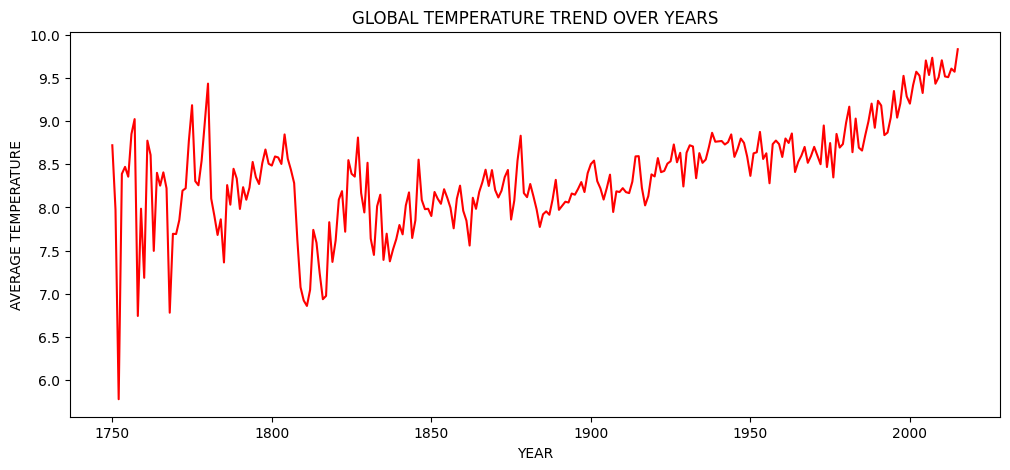

In [14]:
plt.figure(figsize=(12,5))
plt.plot(Yearly_Temperature.index, Yearly_Temperature.values,color='r')
plt.xlabel("YEAR")
plt.ylabel("AVERAGE TEMPERATURE")
plt.title("GLOBAL TEMPERATURE TREND OVER YEARS")
plt.show()

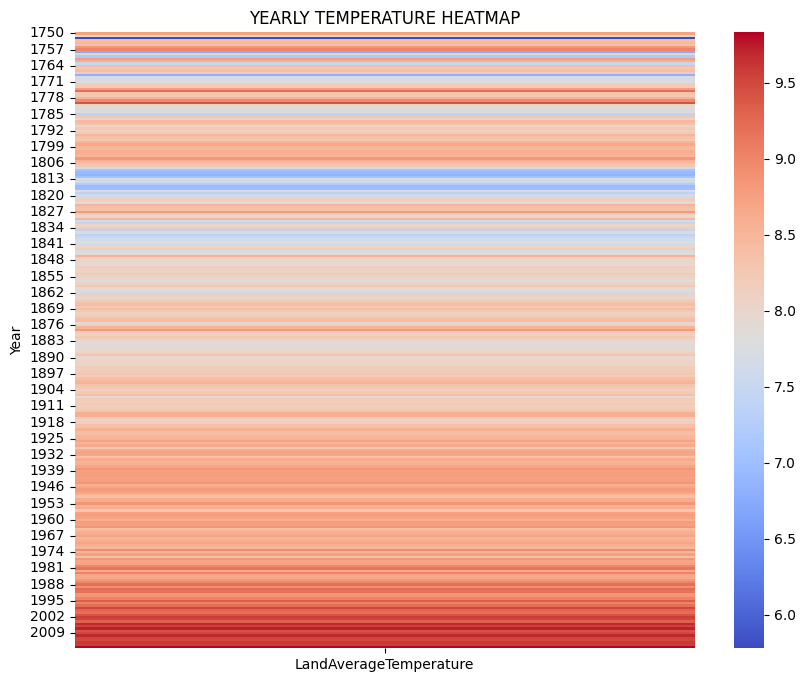

In [21]:
from pickle import TRUE
heatmap_data = df.pivot_table(index= df['Year'], values=['LandAverageTemperature'], aggfunc='mean')

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data,cmap ="coolwarm",annot=False)
plt.title("YEARLY TEMPERATURE HEATMAP")
plt.show()

In [22]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = Yearly_Temperature.index.values.reshape(-1,1)
Y = Yearly_Temperature.values

model = LinearRegression()
model.fit(X,Y)

future_year = np.array([[2050]])
predicted_temp = model.predict(future_year)

print("PREDICTED AVERAGE TEMPERATURE IN 2050 : ",predicted_temp[0])

PREDICTED AVERAGE TEMPERATURE IN 2050 :  9.161895532886051


In [24]:
df.to_csv("Cleaned_Global_Temperatures.csv", index=False)
plt.savefig("Global_Temperature_Trend.png")

<Figure size 640x480 with 0 Axes>